# 17 · Constrained optimisation and linear programming

Engineering design is optimisation *under constraints*: limited machine time, a required volume, a
maximum height. Two very common cases:

- **Linear programming (LP)** - linear objective, linear constraints. Production planning, blending,
  scheduling, transport.
- **Nonlinear constrained optimisation** - e.g. the cheapest vessel of a given volume.

**Problem 1 - production planning.** A workshop builds two pump models. A standard pump earns €400 and
needs 2 h of machining and 1 h of assembly; a heavy-duty pump earns €300 and needs 1 h of machining and
1 h of assembly. Each week there are 100 machining hours and 80 assembly hours, and castings for at
most 40 standard pumps. How many of each should be built?

**What you will learn**

- formulate a production-planning problem as a linear program and solve it by the simplex method
- interpret shadow prices
- solve a nonlinear constrained design problem with the penalty method
- recognise and fix formulation pitfalls (unphysical regions, badly scaled penalties)

**Before you start:** notebooks 10 (Nelder-Mead) and 13 (SymPy); systems of linear inequalities  ·  **Time:** about 60-75 min

Run the cells in order (Shift + Enter). Then change the numbers and run them again - that is how the
ideas sink in.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
from engmath import optimize
from scipy.optimize import linprog, minimize

In [2]:
c = [400, 300]                       # profit per pump (EUR)
A = [[2, 1],                         # machining hours
     [1, 1],                         # assembly hours
     [1, 0]]                         # castings for standard pumps
b = [100, 80, 40]
lp = optimize.simplex_lp(c, A, b)
print(f"optimal plan: {lp.x[0]:.0f} standard + {lp.x[1]:.0f} heavy-duty pumps, profit EUR {lp.objective:,.0f}")
print("corners visited by the simplex method:", [(int(round(v[0])), int(round(v[1]))) for v in lp.vertices])

optimal plan: 20 standard + 60 heavy-duty pumps, profit EUR 26,000
corners visited by the simplex method: [(0, 0), (40, 0), (40, 20), (20, 60)]


## Why the answer is at a corner
Each constraint cuts the plane in half; together they form a convex polygon of feasible plans. Lines of
equal profit are parallel, so the best plan is where the highest profit line last touches the polygon -
**always at a corner**. The simplex method walks from corner to corner, improving the profit each time.

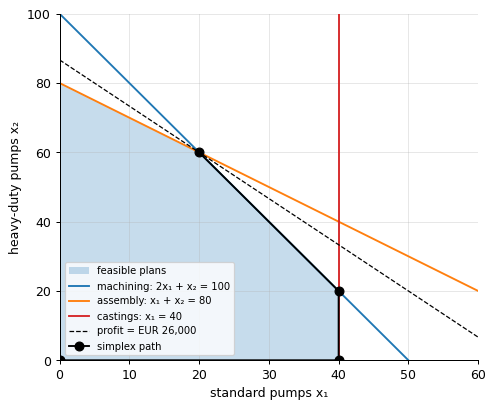

In [3]:
x1 = np.linspace(0, 60, 300)
fig, ax = plt.subplots(figsize=(6, 5))
ax.fill_between(x1, 0, np.minimum(100 - 2*x1, 80 - x1), where=(x1 <= 40) & (np.minimum(100 - 2*x1, 80 - x1) >= 0),
                alpha=0.25, label="feasible plans")
ax.plot(x1, 100 - 2*x1, label="machining: 2x₁ + x₂ = 100")
ax.plot(x1, 80 - x1, label="assembly: x₁ + x₂ = 80")
ax.axvline(40, color="C3", label="castings: x₁ = 40")
ax.plot(x1, (lp.objective - 400*x1)/300, "k--", lw=1, label=f"profit = EUR {lp.objective:,.0f}")
path = np.array(lp.vertices)
ax.plot(path[:, 0], path[:, 1], "ko-", ms=7, label="simplex path")
ax.set(xlim=(0, 60), ylim=(0, 100), xlabel="standard pumps x₁", ylabel="heavy-duty pumps x₂")
ax.legend(fontsize=8); plt.show()

## Inside the algorithm: one simplex step
The simplex tableau holds the constraints (with slack variables) and the objective row. The *entering*
variable is the one with the most negative objective coefficient (the steepest profit increase); the
*leaving* variable follows from the ratio test - the first constraint to become binding:

In [4]:
T = np.zeros((4, 6))
T[:3, :2], T[:3, 2:5], T[:3, -1] = A, np.eye(3), b
T[-1, :2] = [-ci for ci in c]
print("initial tableau (columns x1, x2, s1, s2, s3 | rhs):\n", T)
col = int(np.argmin(T[-1, :-1]))
ratios = np.where(T[:3, col] > 0, T[:3, -1] / np.where(T[:3, col] > 0, T[:3, col], 1), np.inf)
print(f"entering variable: x{col + 1};  ratios {ratios}  ->  constraint {int(np.argmin(ratios)) + 1} becomes binding first")

initial tableau (columns x1, x2, s1, s2, s3 | rhs):
 [[   2.    1.    1.    0.    0.  100.]
 [   1.    1.    0.    1.    0.   80.]
 [   1.    0.    0.    0.    1.   40.]
 [-400. -300.    0.    0.    0.    0.]]
entering variable: x1;  ratios [50. 80. 40.]  ->  constraint 3 becomes binding first


## What are the resources worth?
The **shadow price** of a constraint is the extra profit from one more unit of that resource - the most
you should pay for it. The simplex method delivers these as a by-product:

In [5]:
for name, price in zip(["machining hour", "assembly hour", "casting"], lp.shadow_prices):
    print(f"one more {name:<15}: + EUR {price:6.1f}")
more_assembly = optimize.simplex_lp(c, A, [100, 81, 40])
print(f"check: with 81 assembly hours the profit is EUR {more_assembly.objective:,.0f} "
      f"(+{more_assembly.objective - lp.objective:.0f})")

one more machining hour : + EUR  100.0
one more assembly hour  : + EUR  200.0
one more casting        : + EUR    0.0
check: with 81 assembly hours the profit is EUR 26,200 (+200)


Castings have a shadow price of zero: the constraint is not binding (only 20 of 40 are used), so more
castings are worthless. An extra assembly hour is worth more than an extra machining hour - useful
information for deciding on overtime.

For real problems (thousands of variables) use `scipy.optimize.linprog`; integer requirements (whole
pumps!) need `scipy.optimize.milp`.

In [6]:
ref = linprog([-ci for ci in c], A_ub=A, b_ub=b, method="highs")
print("linprog:", ref.x, " profit", -ref.fun, " shadow prices", -ref.ineqlin.marginals)

linprog: [20. 60.]  profit 26000.0  shadow prices [100. 200.   0.]


## Problem 2 - a nonlinear design: the minimum-material tank
A closed cylindrical tank must hold 1 m³. Which radius $r$ and height $h$ use the least sheet metal
(surface area $2\pi r^2 + 2\pi r h$)? The volume $\pi r^2 h = 1$ is an **equality constraint**. Without
further limits the classic answer - derived with a Lagrange multiplier in SymPy (notebook 13) - is:

In [7]:
import sympy as sp
r_, h_, lam, V = sp.symbols("r h lambda V", positive=True)
Lagr = 2*sp.pi*r_**2 + 2*sp.pi*r_*h_ - lam*(sp.pi*r_**2*h_ - V)
sol = sp.solve([sp.diff(Lagr, v) for v in (r_, h_, lam)], [r_, h_, lam], dict=True)[0]
print("optimum:  r =", sol[r_], "  h =", sol[h_], "  h/r =", sp.simplify(sol[h_]/sol[r_]))

optimum:  r = 2**(2/3)*V**(1/3)/(2*pi**(1/3))   h = 2**(2/3)*V**(1/3)/pi**(1/3)   h/r = 2


**Height equals diameter.** Now add a practical limit - the tank must fit under a 1 m ceiling, $h \le 1$ -
and solve numerically with the **penalty method**: add $\mu\,(\text{violation})^2$ to the objective and
increase $\mu$ step by step, starting from $\mu_0$. This is where formulation mistakes surface.

First, a loophole. The formulas accept *any* numbers, including a negative radius:

In [8]:
area = lambda v: 2*np.pi*v[0]**2 + 2*np.pi*v[0]*v[1]           # v = (r, h)
volume = lambda v: np.pi*v[0]**2*v[1] - 1.0
bad = [-np.sqrt(1/np.pi), 1.0]
print(f"r = {bad[0]:.4f} m, h = 1 m: volume constraint {volume(bad):+.1e}, 'area' = {area(bad):.3f} m²")
for mu0 in (10.0, 1.0):
    with np.errstate(all="ignore"):
        naive = optimize.penalty_minimize(area, [0.5, 1.0], ineq=[lambda v: v[1] - 1.0], eq=[volume], mu0=mu0)
    print(f"penalty method, mu0 = {mu0:4}: r = {naive.x[0]:.4f} m, h = {naive.x[1]:.4f} m, 'area' = {naive.fun:.3f} m²")

r = -0.5642 m, h = 1 m: volume constraint -1.1e-16, 'area' = -1.545 m²
penalty method, mu0 = 10.0: r = 0.5642 m, h = 1.0000 m, 'area' = 5.545 m²
penalty method, mu0 =  1.0: r = -0.5642 m, h = 1.0000 m, 'area' = -1.545 m²


A tank of radius −0.56 m satisfies both constraints with a *negative* "area" - better than any real tank.
With $\mu_0 = 10$ the optimiser happens to stay in the physical region and finds the right answer; with
$\mu_0 = 1$ it wanders across $r = 0$ and exploits the loophole. **Optimisers exploit every loophole in a
formulation**, and whether they find it is a matter of luck. Close it: optimise $\ln r$ and $\ln h$, so
positivity is automatic (or use bounds, as below).

Even then, the penalty weight must be sensible. If $\mu$ starts too small, violating the volume constraint
is cheaper than building a tank:

In [9]:
area_u = lambda u: area(np.exp(u))
vol_u = lambda u: volume(np.exp(u))
h_limit = lambda u: np.exp(u[1]) - 1.0
for mu0 in (1.0, 10.0):
    res = optimize.penalty_minimize(area_u, np.log([0.5, 1.0]), ineq=[h_limit], eq=[vol_u], mu0=mu0)
    r_opt, h_opt = np.exp(res.x)
    print(f"mu0 = {mu0:4}: r = {r_opt:.6f} m, h = {h_opt:.6f} m, volume = {np.pi*r_opt**2*h_opt:.6f} m³")

mu0 =  1.0: r = 0.000000 m, h = 0.000000 m, volume = 0.000000 m³
mu0 = 10.0: r = 0.564190 m, h = 1.000000 m, volume = 1.000000 m³


With $\mu_0 = 1$ the first round shrinks the tank to nothing (the penalty for zero volume, 1, is less than
the area of a real tank, about 5.5 m²) and later rounds cannot recover. **Scale the penalty to the
objective.** With a sensible $\mu_0$ the answer is correct: the height limit is active ($h = 1$ m), so
$r = \sqrt{1/\pi} = 0.5642$ m. SciPy's SLSQP solver handles constraints directly:

In [10]:
slsqp = minimize(area, [0.5, 1.0], method="SLSQP", bounds=[(1e-3, None), (1e-3, None)],
                 constraints=[{"type": "eq", "fun": volume}, {"type": "ineq", "fun": lambda v: 1.0 - v[1]}])
print(f"SLSQP: r = {slsqp.x[0]:.6f} m, h = {slsqp.x[1]:.6f} m, area {slsqp.fun:.4f} m²  (exact r = {np.sqrt(1/np.pi):.6f})")

SLSQP: r = 0.564190 m, h = 1.000000 m, area 5.5449 m²  (exact r = 0.564190)


## Exercises
1. The workshop can buy up to 10 extra assembly hours at EUR 150 per hour. Should it? Use the shadow
   price, then confirm by re-solving.
2. **Whole pumps.** A redesigned standard pump needs 2.4 h of machining, and 105 machining hours are
   available. Solve the LP, then round its solution to whole pumps (to the nearest integer, and
   downwards). Are the rounded plans feasible? Optimal? Compare with `scipy.optimize.milp`, which
   requires whole numbers.
3. The tank's end caps must be twice as thick as its wall. Minimise the material *volume*
   ($2\cdot 2\pi r^2 t + 2\pi r h t$). How does the optimal $h/r$ change? Derive it with SymPy.
4. **Implement it yourself:** the *log-barrier* (interior-point) method minimises $f(x) - \mu\sum\ln(-g_i(x))$ for decreasing $\mu$, staying strictly feasible. Implement it with `optimize.nelder_mead` for the tank with $h \le 1$ (eliminate the volume constraint first) and compare with the penalty method.